In [1]:
import numpy as np
import pandas as pd
import csv
from scipy.constants import mu_0, epsilon_0
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets
import discretize
import  os
import json
from PIL import Image
import seaborn as sns
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import ipywidgets as widgets
eps = np.finfo(float).eps

In [63]:
import empymod
from scipy.special import logsumexp

from masa_utils import PsuedoLog, Optimization
from masa_utils import empymod_IP_simulation,TEM_Signal_Process
from masa_utils import multiple_dataset_simulation

Simulatin and synthetic study on deep sea hydrothermal deposits explortaion using WISTEM (K. Nakayama and A. Saito, 2016) (K.Nakayama M. Motoori and A. Saito,2019). On-Time: 200msec ramp time: 200usec Transmitter Loop: 3.5m Square Loop Receiver Loop: Coincident-type Number of Turn: 5 3.5m rectangular loop has equivalent area for 2.0m circular loop.

In [3]:
plt.style.use('00_figures.mplstyle')
textwidth = 5.60739


In [4]:
# --- helper to render LaTeX labels (robust method) ---
def math_label(tex, width="160px"):
    out = widgets.Output(layout=widgets.Layout(width=width))
    with out:
        display(Math(tex))
    return out
def sci_latex(v, prec=2):
    s = f"{v:.{prec}e}"          # e.g. '3.00e-03'
    mant, exp = s.split('e')
    exp = int(exp)

    if float(mant) == 0:
        return "0"

    if exp in [0, -1]:
        return f"{float(mant)*10**exp:.{prec}f}"
    else:
        return rf"{mant}\cdot 10^{{{exp}}}"


def fmt(v, prec=2, latex=False, wrap=False):
    # blank for None or empty string
    if v is None or v == "":
        return ""

    # if already string → return as-is
    if isinstance(v, str):
        return v

    try:
        s = sci_latex(v, prec=prec)

        if latex:
            if wrap:
                return rf"$${s}$$"   # display math
            else:
                return rf"${s}$"     # inline math
        else:
            return s

    except:
        return ""


In [5]:

rmp_time=200e-6

smp_freq=50e3 #200e3  

In [6]:
tx_side = 3.5
tx_radius = (tx_side)/(np.sqrt(np.pi))
tx_circumeference = 2*np.pi*tx_radius
tx_surface = np.pi*tx_radius**2
n_turns = 5
tx_depth = 0
print(f"Transmitter radius: {tx_radius}")

Transmitter radius: 1.9746635424171473


In [7]:
tstrt, tend = 1e-4, 1e-2
logstep = 1/15
WISTEM_SP_sim = TEM_Signal_Process(
    rmp_time=rmp_time, 
    rec_time=tend, 
    smp_freq=smp_freq
)


In [8]:
times_sim = WISTEM_SP_sim.times_rec
times_clc = WISTEM_SP_sim.times_rec
ntimes = len(times_clc)
print(ntimes)
print(times_clc[:3], times_clc[-3:])
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
windows_strt = WISTEM_SP_sim.windows_strt
windows_cen = WISTEM_SP_sim.windows_cen
windows_end = WISTEM_SP_sim.windows_end
print(windows_cen-rmp_time)
nD = len(windows_cen)

500
[2.e-05 4.e-05 6.e-05] [0.00996 0.00998 0.01   ]
[0.0001     0.00011651 0.00013575 0.00015817 0.00018429 0.00021472
 0.00025018 0.00029149 0.00033962 0.0003957  0.00046104 0.00053718
 0.00062588 0.00072923 0.00084965 0.00098995 0.00115342 0.00134388
 0.0015658  0.00182436 0.00212561 0.00247661 0.00288558 0.00336207
 0.00391725 0.0045641  0.00531777 0.00619589 0.00721901 0.00841108]


In [9]:
nlayer, nlayer_target =10,5
nlayer_bottom = nlayer-nlayer_target
eta_sea , eta_base = 0.,0.
tau_sea, tau_base = 1e-3, 1e-3
c_sea, c_base = 0.5,.5
thick_layer = 2.
res_sea, res_target, res_base = 0.3, 0.1,10
depth = thick_layer*np.arange(nlayer)
tx_height = 0.1

depth+=tx_height
print(f"depth {depth}")

depth [ 0.1  2.1  4.1  6.1  8.1 10.1 12.1 14.1 16.1 18.1]


In [10]:
m_true = np.r_[np.log(res_target)*np.ones(nlayer_target),
               np.log(res_base)*np.ones(nlayer_bottom)]


In [11]:
nmodel=5 #4
# res_ref_list = [10,3,1.0,0.3]
res_ref_list = [3.0,1.0,0.5,0.3,0.2]
m_refs = []

for res_ref in res_ref_list:
    m_ref = np.log(res_ref)*np.ones(nlayer)
    m_refs.append(m_ref)
m_ref_multi=np.array(m_refs).flatten()

print(f"m_ref_multi {m_ref_multi}")

m_ref_multi [ 1.09861229  1.09861229  1.09861229  1.09861229  1.09861229  1.09861229
  1.09861229  1.09861229  1.09861229  1.09861229  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.69314718 -0.69314718 -0.69314718 -0.69314718
 -0.69314718 -0.69314718 -0.69314718 -0.69314718 -0.69314718 -0.69314718
 -1.2039728  -1.2039728  -1.2039728  -1.2039728  -1.2039728  -1.2039728
 -1.2039728  -1.2039728  -1.2039728  -1.2039728  -1.60943791 -1.60943791
 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791 -1.60943791
 -1.60943791 -1.60943791]


In [12]:
WISTEM_SP_sim.get_window_log(tstart=tstrt,logstep=logstep)
filt_linrmp = WISTEM_SP_sim.filter_linear_rmp()

Window_mat = WISTEM_SP_sim.get_window_matrix(times_sim)
print(Window_mat.shape)

(30, 500)


In [13]:
recx, recy = 0 , 0
recBdple = [recx, recy, tx_depth ,0,90]
# recx, recy, recw = rec_area(3, tx_side)
# recBdple = [recx, recy, tx_depth ,0,90]

In [14]:
# emoymod model to simulate WISTEM setting
# Note that it simulate only dBdt field at center of the transmitter loop
# User should multiply by area of the loop to get EMF(V/A)
empymod_model_sim = {
    # simulate each bipole of four side of the transmitter loop
    'src': [ tx_side/2, tx_side/2,  # x1,x2
                     0, tx_side/2,  # y1,y2
             tx_depth, tx_depth], # z1,z2
    # receiver at the center of the transmitter loop
    'rec': recBdple, # [recx, recy, tx_depth ,0,90], # dBzdt at x,y,z,azimuth,dip
    'depth': depth,
#    'res' : res,
#    'freqtime': times_sim,
    'signal': None, # 0: impulse or dBdt, 1: Stepoff or B field
    'msrc' : False, # Electric source
    'mrec' : True, # Magnetic receiver
    'strength': 8.*n_turns* tx_surface * mu_0,  
    'srcpts' : 3,  # Three works for the momtent, maybe worth seeking other number
    'verb': 0, # put 4 for more information
     # Setting xdirect=True can help, as direct field is then computed analytically in f-domain
    'xdirect': True,
}

In [15]:
sim=empymod_IP_simulation(ip_model='pelton',
    model_base=empymod_model_sim, nlayer=nlayer,tx_height=tx_height,
    times=times_sim, smp_freq=smp_freq,nD=nD
    )
sim.deepsea_noIP(
    res_sea=res_sea, 
    eta_sea=eta_sea, tau_sea=tau_sea, c_sea=c_sea,
    eta_base=eta_base, tau_base=tau_base, c_base=c_base 
    )


In [16]:
print(sim.m_fix)
print(sim.model_base)

[-1.2039728   0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -6.90775528 -6.90775528
 -6.90775528 -6.90775528 -6.90775528 -6.90775528 -6.90775528 -6.90775528
 -6.90775528 -6.90775528 -6.90775528  0.5         0.5         0.5
  0.5         0.5         0.5         0.5         0.5         0.5
  0.5         0.5       ]
{'src': [1.75, 1.75, 0, 1.75, 0, 0], 'rec': [0, 0, 0, 0, 90], 'depth': array([ 0.1,  2.1,  4.1,  6.1,  8.1, 10.1, 12.1, 14.1, 16.1, 18.1]), 'signal': None, 'msrc': False, 'mrec': True, 'strength': np.float64(0.0006157521600223001), 'srcpts': 3, 'verb': 0, 'xdirect': True}


In [17]:
mvec_obs = m_true
sim.cut_off = None
dpred_step= sim.dpred(mvec_obs)
sim.cut_off = smp_freq/2.0
print(f"cutoff frequency: {sim.cut_off}")
dpred_LPF = sim.dpred(mvec_obs)
sim.filt_curr = filt_linrmp
dpred_rmp = sim.dpred(mvec_obs)
sim.window_mat=Window_mat
dpred_window = sim.dpred(mvec_obs)

cutoff frequency: 25000.0


In [18]:
PL_decay = PsuedoLog(
    logmin=1e-8,
    linScale=0.5,
    logminx=1e-4,
    linScalex=0.5
    )
PL_jac = PsuedoLog(
    logmin=1e-8,
    linScale=0.5,
    logminx=1e-4,
    linScalex=0.2
    )

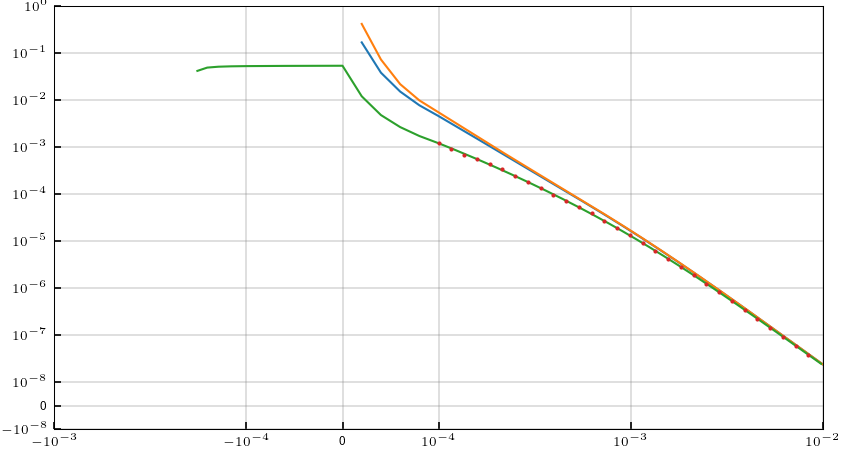

In [19]:
fig, ax= plt.subplots(1,1, figsize=(textwidth,3))

ax= PL_decay.plpl_plot(
     x=times_clc,y=dpred_step , linestyle="-",label="obs", color="C0",ax=ax)
ax= PL_decay.plpl_plot(
     x=times_clc,y=dpred_LPF , linestyle="-",label="Low Pass filtered", color="C1",ax=ax)
ax= PL_decay.plpl_plot(
     x=times_clc-rmp_time,y=dpred_rmp , linestyle="-",label="wvf", color="C2",ax=ax)
ax= PL_decay.plpl_plot(
     x= windows_cen-rmp_time,y=dpred_window , marker="o",linestyle="",label="windowed", color="C3",ax=ax)
ax= PL_decay.pl_axes(ax)
ax= PL_decay.pl_axes_x(ax)


In [20]:
relative_error=0.05
data_noise_floor = 0.1e-7



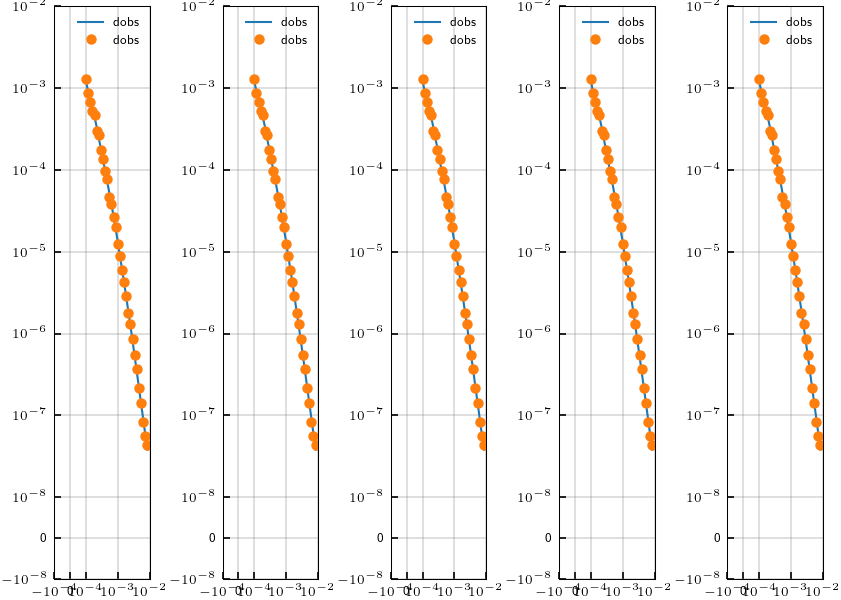

In [21]:
fig, ax= plt.subplots(1,nmodel, figsize=(textwidth,4))
dobs_cmb =[]
ax= ax.flatten()
m_true_multi = []
dobs_multi = []
 # For reproducibility
for i in range(nmodel):
   # np.random.seed(i) # if you wanto have different noise for each model 
    # if you want the same noise for each model

   np.random.seed(1)
   # Calculate noise floor and relative erro at each window
   mvec_obs = m_true
   dobs_clean=sim.dpred(mvec_obs)
   noise_floor = data_noise_floor
   noise_relative = relative_error * np.abs(dobs_clean)

   # Combine the two sources of noise
   total_noise = np.sqrt(noise_floor**2 + noise_relative**2)

   # Add the combined noise to the clean data
   dobs = dobs_clean +  np.random.randn(len(dobs_clean)) * total_noise

   dobs_cmb.append(dobs)
   m_true_multi.append(m_true)
   dobs_multi.append(dobs)
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs_clean, 
      label="dobs", color="C0", linestyle="-",ax=ax[i]
   )
   ax[i]=PL_decay.plpl_plot(x= windows_cen-rmp_time,y=dobs, 
      label="dobs", color="C1", marker="o",markersize=4,linestyle="",ax=ax[i]
   )
   ax[i]= PL_decay.pl_axes(ax[i])
   ax[i]= PL_decay.pl_axes_x(ax[i])
#for ax in ax:

   ax[i].legend()
m_true_multi = np.array(m_true_multi).flatten()
dobs_multi = np.array(dobs_multi).flatten()


# Inversion

In [22]:
niter = 50
stol=1e-6
coolingFactor = np.sqrt(2) #2.0
coolingRate = 2
mu=1e-2
beta0_ratio = 1
alphas, alphax = 1.0, 1.0
Ws_threshold=1e-3

In [23]:
dobs_cmb

[array([1.31156553e-03, 8.70995880e-04, 6.73539426e-04, 5.19105518e-04,
        4.64335946e-04, 2.99472436e-04, 2.65644581e-04, 1.76956396e-04,
        1.37480843e-04, 9.63897028e-05, 7.85563985e-05, 4.70804471e-05,
        3.82302494e-05, 2.65157340e-05, 2.01165929e-05, 1.25836988e-05,
        8.98439554e-06, 5.93483510e-06, 4.23445009e-06, 2.91592644e-06,
        1.78593853e-06, 1.32459180e-06, 8.59406278e-07, 5.49178799e-07,
        3.64308854e-07, 2.13518332e-07, 1.42445775e-07, 8.27692788e-08,
        5.68378855e-08, 4.36055067e-08]),
 array([1.31156553e-03, 8.70995880e-04, 6.73539426e-04, 5.19105518e-04,
        4.64335946e-04, 2.99472436e-04, 2.65644581e-04, 1.76956396e-04,
        1.37480843e-04, 9.63897028e-05, 7.85563985e-05, 4.70804471e-05,
        3.82302494e-05, 2.65157340e-05, 2.01165929e-05, 1.25836988e-05,
        8.98439554e-06, 5.93483510e-06, 4.23445009e-06, 2.91592644e-06,
        1.78593853e-06, 1.32459180e-06, 8.59406278e-07, 5.49178799e-07,
        3.64308854e-07

In [24]:
models_rec = []
dpreds = []
error_prgs = []
model_prgs = []
dinit_refs = []
data_prgs =[]
for i in range(nmodel):
    m_ref = m_refs[i]
    dobs = dobs_cmb[i]
    opt = Optimization(
        sim=sim, dobs=dobs, 
        alphas=alphas, alphax=alphax, 
        Ws_threshold=Ws_threshold
        )
    opt.get_Wd(ratio=relative_error, plateau=noise_floor)
    Wd=opt.Wd
    smallness = np.ones(nlayer)
    opt.get_Ws(smallness=smallness)
    Ws = opt.get_Wx_r()
    beta0 = opt.BetaEstimate_byEig(
        mvec=m_ref, update_Wsen=True, beta0_ratio=beta0_ratio)
    print(beta0)
    mpred = opt.GaussNewton(
    mvec_init=m_ref,niter=niter,beta0=beta0, update_Wsen=True,
    stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
    )
    
    dinit_refs.append(opt.dpred(m_ref))
    models_rec.append(mpred)
    dpreds.append(opt.dpred(mpred))
    error_prgs.append(opt.error_prg)
    model_prgs.append(opt.mvec_prg)
    data_prgs.append(opt.data_prg)


5.691848525495021
  1, beta:5.7e+00, step:2.5e-01, g:5.9e+01, phid:1.2e+03, phim:6.6e+00, f:1.2e+03 
  2, beta:5.7e+00, step:2.5e-01, g:4.3e+02, phid:3.4e+02, phim:2.4e+01, f:4.7e+02 
  3, beta:4.0e+00, step:1.0e+00, g:5.4e+02, phid:1.1e+02, phim:1.5e+01, f:1.7e+02 
  4, beta:4.0e+00, step:1.0e+00, g:1.0e+03, phid:1.7e+01, phim:8.6e+00, f:5.2e+01 
  5, beta:2.8e+00, step:1.0e+00, g:9.3e+01, phid:1.6e+01, phim:9.2e+00, f:4.2e+01 
  6, beta:2.8e+00, step:1.0e+00, g:9.1e+00, phid:1.6e+01, phim:9.1e+00, f:4.2e+01 
  7, beta:2.0e+00, step:1.0e+00, g:2.2e+00, phid:1.5e+01, phim:9.3e+00, f:3.4e+01 
  8, beta:2.0e+00, step:1.0e+00, g:7.0e+00, phid:1.6e+01, phim:9.0e+00, f:3.4e+01 
  9, beta:1.4e+00, step:1.0e+00, g:1.5e+00, phid:1.5e+01, phim:9.2e+00, f:2.8e+01 
 10, beta:1.4e+00, step:1.0e+00, g:6.9e+00, phid:1.5e+01, phim:8.9e+00, f:2.8e+01 
 11, beta:1.0e+00, step:1.0e+00, g:9.8e-01, phid:1.5e+01, phim:9.1e+00, f:2.4e+01 
 12, beta:1.0e+00, step:1.0e+00, g:6.5e+00, phid:1.5e+01, phim:8.9e+0

In [25]:
Ws = opt.Ws
print(np.diag(Ws))

[1.         0.52411208 0.39539144 0.23931347 0.0983048  0.0391299
 0.01700643 0.00814594 0.00423847 0.01019424]


In [26]:
phid_star=0.5*len(windows_cen)
models_rec_phid = []
dpreds_phid = []
phid_star_ratio =1.1
phid_itrs = []
for i in range(nmodel):
    model_prg= np.array(model_prgs[i])
    data_prg = np.array(data_prgs[i])
    error_prg = error_prgs[i]
    phid_prg = np.array(error_prg)[:,1]
    ind = phid_prg < phid_star*phid_star_ratio
    if np.sum(ind) == 0:
        ind = phid_prg == np.min(phid_prg)

        print(f"No iteration below phid_star, take min phid{np.where(ind)[0][0]}")
    phid_itr = np.where(ind)[0][0]
    models_rec_phid.append(model_prg[ind][0])
    dpreds_phid.append(data_prg[ind][0])
    phid_itrs.append(phid_itr)
models_rec_phid_multi = np.array(models_rec_phid).flatten()

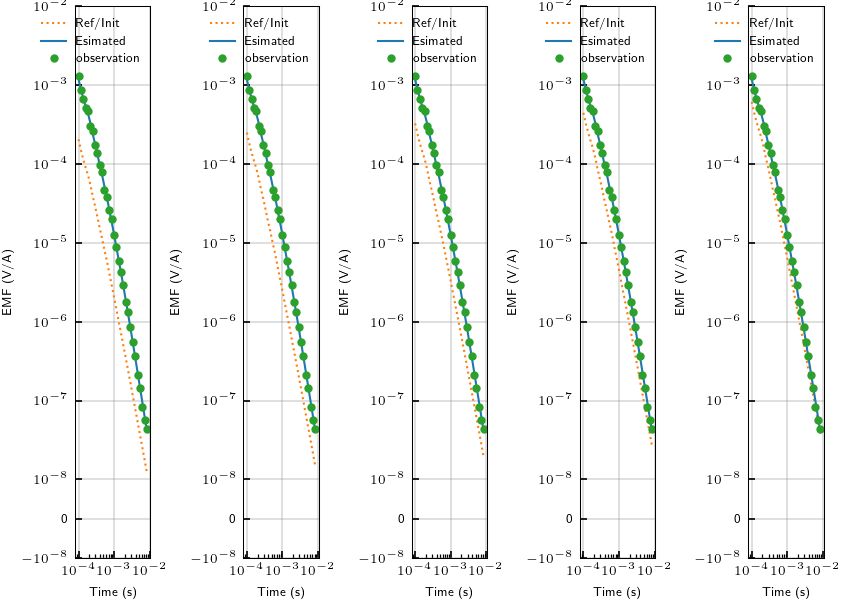

In [27]:
fig, ax= plt.subplots(1,nmodel, figsize=(textwidth,4))
ax= ax.flatten()
for i in range(nmodel):
    dobs= dobs_cmb[i]   
    dinit_ref = dinit_refs[i]

    ax[i]=PL_decay.semiply(
        windows_cen-rmp_time, dinit_ref, ax=ax[i],
        color=f"C1",linestyle=":", label=f"Ref/Init"
        )

    ax[i]=PL_decay.semiply(
        windows_cen-rmp_time, dpreds_phid[i], ax=ax[i],
        color=f"C0",linestyle="-", label=f"Esimated"
        )
    ax[i]=PL_decay.semiply(
        windows_cen-rmp_time, dobs, ax=ax[i], marker="o",markersize=3.0,
        color=f"C2",linestyle="", label="observation"
        )
    ax[i] = PL_decay.pl_axes(ax[i])

    ax[i].legend()
    ax[i].set_xlabel("Time (s)")
    ax[i].set_ylabel("EMF (V/A)")


In [28]:
def plot_data( ax=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
    for i in range(nmodel):
        color = f"C{i}"
        ax=PL_decay.semiply(windows_cen-rmp_time, dinit_refs[i], ax=ax,
                        color=color,linestyle=":"
                        )
    for i in range(nmodel):
        color = f"C{i}"
        label = r"$\rho_0$: "+f"{res_ref_list[i]:.1f}"
        ax=PL_decay.semiply(windows_cen-rmp_time, dpreds_phid[i], ax=ax
                            ,color=color,linestyle="-",label=label
                            )

    ax=PL_decay.semiply(
        windows_cen-rmp_time, dobs, ax=ax, marker="o",markersize=2.0,
        color="k",linestyle="", label="observation"
        )
    ax = PL_decay.pl_axes(ax)
    ax.legend()
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("EMF (V/A)")
    ax.set_title(f""" Data plot
Relative error {relative_error*100:.1f} %, noise floor {data_noise_floor:.1e} V/A""")
    return ax

In [29]:
res_ref_list

[3.0, 1.0, 0.5, 0.3, 0.2]

In [34]:
def plot_resistivity(ax):


    for i in range(nmodel):
        color = f"C{i}"
        label = None
        m_ref = m_refs[i]
        model= sim.get_ip_model(m_ref)
        ax = sim.plot_model(model["res"], 
                color=color, linestyle=":",label=label,ax=ax) 
    for i in range(nmodel):
        color = f"C{i}"
        label = r"$\rho_0$: "+f"{res_ref_list[i]:.1f}"
        m_tem = models_rec_phid[i]
        model= sim.get_ip_model(m_tem)
        ax = sim.plot_model(model["res"], 
            color=color, linestyle="-", label=label,ax=ax)
    color = "k"
    model= sim.get_ip_model(m_true)
    ax = sim.plot_model(model["res"], 
        color=color, linestyle=":",label="True",linewidth=2, ax=ax)
    ax.set_xlim([30,0.03])
    ax.legend()
    ax.axhline(empymod_model_sim["src"][4], color="k", linestyle="-", label="Src+Rec")
    ax.set_ylim([25, -5.0])
    ax.set_ylabel('depth')
    ax.set_xscale("log")
    ax.set_title(r"$\rho_0$ (ohm-m)")
    return ax

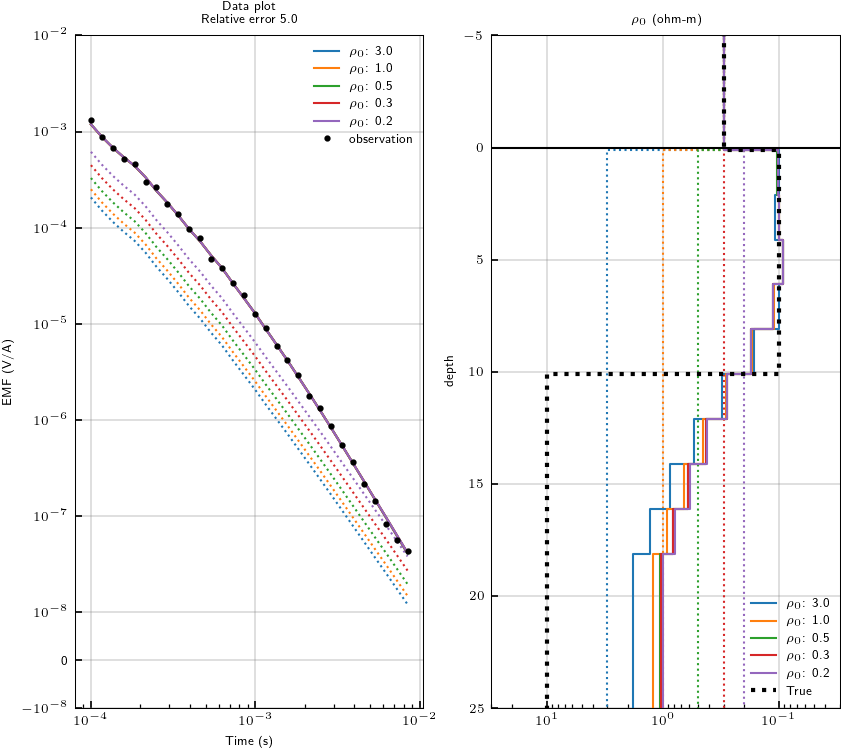

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(textwidth,5))
ax = ax.flatten()

ax[0]=plot_data(ax=ax[0])
ax[1]=plot_resistivity(ax=ax[1])

plt.savefig("../figures/10_multiple_layers.png", bbox_inches="tight")

In [32]:

res_rec = np.exp(models_rec_phid_multi)
print(f"res_rec {res_rec}")

res_rec [0.09980936 0.10749305 0.0919728  0.09888559 0.16524364 0.30805247
 0.54080297 0.86792843 1.29110509 1.81554261 0.10271121 0.10039188
 0.09255482 0.10918985 0.1715519  0.28446867 0.4491133  0.66304068
 0.92155132 1.2195659  0.10314547 0.09920301 0.09273511 0.11209173
 0.17365549 0.27903478 0.42613788 0.60992987 0.82398916 1.06210117
 0.10264787 0.09992893 0.09250135 0.11206323 0.17417271 0.27936459
 0.42482524 0.60502641 0.81326811 1.04320267 0.10247354 0.09994971
 0.09253353 0.11303943 0.1749354  0.27734615 0.41629641 0.58549387
 0.77787113 0.98696659]


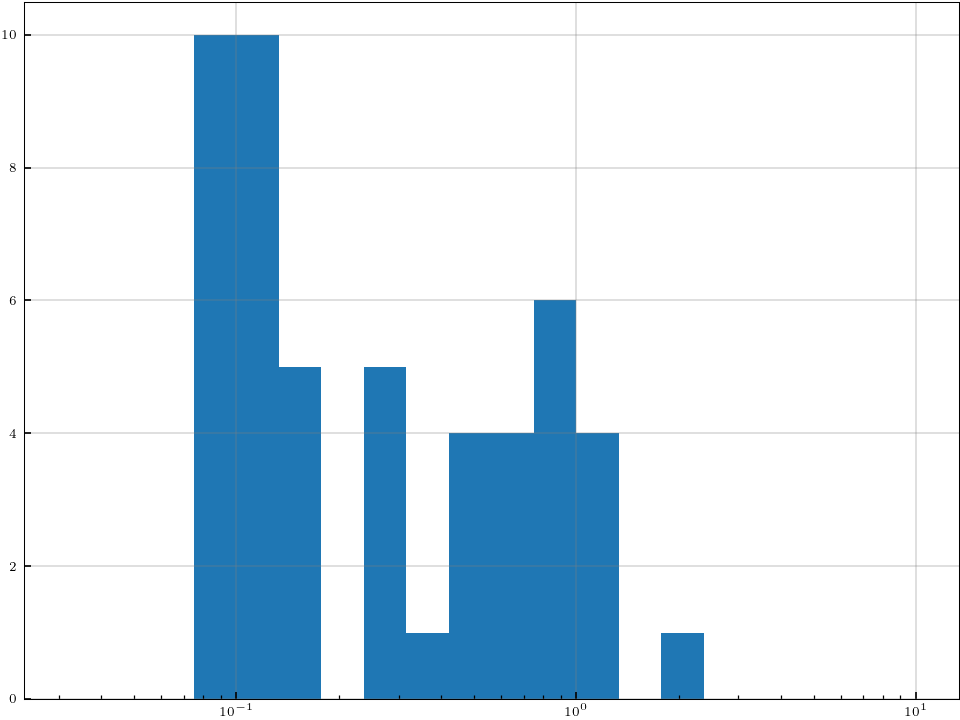

In [37]:
bins = np.logspace(-1.5,1.0,num=21)
plt.hist(res_rec, bins=bins)
plt.xscale("log")

# Merge dataset 

In [136]:
simulation_list = []
for i in range(nmodel):
    simulation_list.append(sim)

sim_multidata = multiple_dataset_simulation(
    simulation_list=simulation_list)
sim_multidata.nD_indices

[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
 array([30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
        47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59]),
 array([60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76,
        77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]),
 array([ 90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102,
        103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115,
        116, 117, 118, 119]),
 array([120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
        133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145,
        146, 147, 148, 149])]

# Inversion with GMM manually

In [137]:
from scipy.special import logsumexp

class Optimization_GMM:  # Inherits from BaseSimulation
    def __init__(self,
                sim, # BaseSimulation,
                dobs=None,
                Wd=None, Ws=None, Wx=None, alphas=1, alphax=1,
                Ws_threshold=1e-6, eig_tol=1e-6
                ):
        self.sim = sim  # Composition: opt_tmp has a simulation
        self.dobs= dobs
        self.Wd = Wd
        self.Ws = Ws
        self.Ws_threshold = Ws_threshold
        self.Wx = Wx
        self.eig_tol = eig_tol
        self.alphas = alphas
        self.alphax = alphax

    def dpred(self, m):
        return self.sim.dpred(m)  # Calls InducedPolarization's dpred()

    def J(self, m):
        return self.sim.J(m)  # Calls InducedPolarization's J()
    
    def project_convex_set(self,m):
        return self.sim.project_convex_set(m)

    def get_Wd(self,ratio=0.10, plateau=0):
        dobs_clone = self.dobs.copy()
        noise_floor = plateau * np.ones_like(dobs_clone)
        noise_relative = dobs_clone * ratio
        std = np.sqrt(noise_floor**2 + noise_relative**2)
        self.Wd =np.diag(1 / std.flatten())
    
    def get_Ws(self, smallness):
        # if self.sim.nM is not None:
        #     self.Ws = np.eye(self.sim.nM)
        # else:
        self.smallness= smallness
        self.Ws = np.diag(smallness)

    def update_Ws(self, J):
        if self.Wd is None:
            Sensitivity = np.sqrt(np.sum(J**2, axis=0))
        else:
            Sensitivity = np.sqrt(np.sum((self.Wd@J)**2, axis=0))
        # Sensitivity = self.compute_sensitivity(self.Wd@J)
        Sensitivity /= Sensitivity.max()
        Sensitivity = np.clip(Sensitivity, self.Ws_threshold, 1)
        self.Ws = np.diag(self.smallness*Sensitivity)

    def loss_func_GMM(self,m,
             beta_GMM, 
             means,
             weights,
             covariances,
             gamma,
             gradient=False,
             update_Wsen=False
             ):
        self.K=len(weights)
        self.inv_covariances = [np.linalg.inv(cov) for cov in covariances]
        if gradient:
            J = self.J(m)
            if update_Wsen:
                self.update_Ws(J)
            dpred_m = self.dpred(m)            
            rd = self.Wd @ (dpred_m -self.dobs)
            phid = 0.5 * np.dot(rd,rd)
            g = J.T @ self.Wd.T@ rd
            H = J.T @ self.Wd.T@ self.Wd@J
            phim = 0
            for j in range(self.K):
                rms = gamma[:,j]*(m-means[j])
                if self.K>1:
                    phim += 0.5  * weights[j] * (
                        rms.T@ self.inv_covariances[j] @ rms
                        )
                    g += beta_GMM * (self.inv_covariances[j] @ rms)
                else:
                    phim += 0.5  * weights[j] * (rms.T@rms/inv_covariances[j])
                H += beta_GMM * self.inv_covariances[j]
            f= phid+beta_GMM*phim
            return f, phid, phim, dpred_m, g, H
        else:
            dpred_m = self.dpred(m)            
            rd = self.Wd @ (dpred_m-self.dobs)
            phid = 0.5 * np.dot(rd,rd)
            phim = 0
            for j in range(self.K):
                rms = gamma[:,j]*(m-means[j])
                if self.K>1:
                    phim += 0.5  * weights[j] * (
                        rms.T@ self.inv_covariances[j] @ rms
                        )
                else:
                    phim += 0.5  * weights[j] * (rms.T@rms/inv_covariances[j])
            f= phid+beta_GMM*phim
            return f, phid, phim, dpred_m

    def GMM_regularization(self,mvec_init,
                weights, means, covariances, niter, beta0, print_update=True, 
        coolingFactor=2.0, coolingRate=2, s0=1.0, sfac=0.5,update_Wsen=False,
        stol=1e-6, gtol=1e-3, mu=1e-4):
        self.error_prg = []
        self.data_prg = []
        self.mvec_prg = []
        self.betas = []
        self.weights_prg = []
        self.means_prg = []
        self.covariances_prg = []
        weights = weights.copy()
        means = means.copy()
        covariances = covariances.copy()
        mvec_old = mvec_init.copy()
        m_ref = mvec_init
        beta= beta0
        gamma = gmm_e_step(
                x=mvec_old,
                  weights=weights, means=means, covariances=covariances) 
        f_old, phid, phim = self.loss_func_GMM(
            mvec_old,beta, means=means, weights=weights,
                covariances=covariances,gamma=gamma, gradient=False, update_Wsen=True)
        
        for i in range(niter):
            dpred_old = self.dpred(mvec_old)
            self.betas.append(beta)
            self.error_prg.append([f_old, phid, phim])
            self.mvec_prg.append(mvec_old)
            self.data_prg.append(dpred_old)

            beta = beta0 / (coolingFactor ** (i // coolingRate))
            gamma = gmm_e_step(
                x=mvec_old,
                  weights=weights, means=means, covariances=covariances)            
            f, phid, phim, dpred_m, g, H = self.loss_func_GMM(
                mvec_old,beta, means=means, weights=weights, gamma=gamma,
                covariances=covariances, gradient=True, update_Wsen=update_Wsen
                )

            dm = np.linalg.solve(H, g)  # Ensure dm is a 1D tensor
            g_norm = np.linalg.norm(g, ord=2)
            self.weights_prg.append(weights)
            self.means_prg.append(means)
            self.covariances_prg.append(covariances)

            if g_norm < gtol:
                print(f"Inversion complete since norm of gradient is small as: {g_norm:.3e}")
                break
            s = s0
            mvec_new = self.project_convex_set(mvec_old - s * dm)
            f_new, phid, phim = self.loss_func_GMM(mvec_new,beta, m_ref=m_ref)# phid
            directional_derivative = np.dot(g.flatten(), -dm.flatten())
            while f_new >= f_old + s * mu * directional_derivative:
                s *= sfac
                mvec_new = self.project_convex_set(mvec_old - s * dm)
                f_new, phid, phim = self.loss_func_GMM(mvec_new,beta,m_ref=m_ref) #phid
                if s < stol:
                    break
            mvec_old = mvec_new
            f_old = f_new

            weights, means, covariances = gmm_m_step(
                mvec_new, gamma)
            if print_update:
                print(f'{i+1:3}, beta:{beta:.1e}, step:{s:.1e}, g:{g_norm:.1e}, phid:{phid:.1e}, phim:{phim:.1e}, f:{f_new:.1e} ')

        self.error_prg.append([f_new, phid, phim])
        self.mvec_prg.append(mvec_new)
        self.data_prg.append(self.dpred(mvec_new))
        self.betas.append(beta)
        self.weights_prg.append(weights)
        self.means_prg.append(means)
        self.covariances_prg.append(covariances)

        return mvec_new

def gaussian_logpdf(x, mean, cov):
    """
    Log probability of multivariate Gaussian.

    x    : (N, D)
    mean : (D,)
    cov  : (D, D)
    """

    diff = x - mean

    sign, logdet = np.linalg.slogdet(cov)

    if sign <= 0:
        raise ValueError("Covariance matrix must be positive definite.")

    # Do not explicitly calculate inverse
    tmp = np.linalg.solve(cov, diff.T).T

    mahal = np.sum(diff * tmp, axis=1)

    D = x.shape[1]

    return -0.5 * (
        D * np.log(2.0 * np.pi)
        + logdet
        + mahal
    )

def gmm_e_step(x, weights, means, covariances):
    """
    Calculate responsibility gamma_ik.

    x           : (N, D)
    weights     : (K,)
    means       : (K, D)
    covariances : (K, D, D)
    """

    N = x.shape[0]
    K = len(weights)

    log_prob = np.zeros((N, K))

    for k in range(K):

        log_prob[:, k] = (
            np.log(weights[k])
            + gaussian_logpdf(
                x,
                means[k],
                covariances[k]
            )
        )

    # log p(x_i)
    log_norm = logsumexp(
        log_prob,
        axis=1,
        keepdims=True
    )

    # responsibility
    gamma = np.exp(log_prob - log_norm)
    return gamma

def gmm_m_step(x, gamma, reg_covar=1e-6):

    N, D = x.shape
    K = gamma.shape[1]

    Nk = np.sum(gamma, axis=0)

    weights = Nk / N

    means = np.zeros((K, D))
    covariances = np.zeros((K, D, D))

    for k in range(K):

        # mean
        means[k] = (
            gamma[:, k, None] * x
        ).sum(axis=0) / Nk[k]

        # covariance
        diff = x - means[k]

        covariances[k] = (
            (gamma[:, k, None] * diff).T
            @ diff
        ) / Nk[k]

        # Prevent singular covariance
        covariances[k] += (
            reg_covar * np.eye(D)
        )
    return weights, means, covariances    

In [138]:
maxiter = 10
weights = np.array([0.5, 0.5])
K = 2
D = 1
mvec_init_multi = models_rec_phid_multi
means = np.array([
    [-1.0],
    [ 1.0]
])

covariances = np.array([
    [[0.5]],
    [[0.5]],
])
X = models_rec_phid_multi.reshape(-1, 1)
for i in range(maxiter):

    gamma = gmm_e_step(
        X,
        weights,
        means,
        covariances
    )

    weights, means, covariances = gmm_m_step(
        X,
        gamma
    )

In [139]:
print(f"weights: {weights}")
print(f"means: {means.flatten()}")  
print(f"covariances: {covariances.flatten()}")
print(f"gamma: {gamma}")


weights: [0.66756124 0.33243876]
means: [-1.90116354 -0.1888079 ]
covariances: [0.29688888 0.134196  ]
gamma: [[9.99999992e-01 8.28037197e-09]
 [9.99999973e-01 2.68233112e-08]
 [9.99999998e-01 2.19333048e-09]
 [9.99999993e-01 7.13163931e-09]
 [9.99985950e-01 1.40504069e-05]
 [9.77644405e-01 2.23555946e-02]
 [2.31524976e-01 7.68475024e-01]
 [1.57880347e-02 9.84211965e-01]
 [3.29406004e-03 9.96705940e-01]
 [1.61651513e-03 9.98383485e-01]
 [9.99999987e-01 1.30844018e-08]
 [9.99999991e-01 9.08960154e-09]
 [9.99999998e-01 2.43299673e-09]
 [9.99999966e-01 3.42571227e-08]
 [9.99976816e-01 2.31836313e-05]
 [9.90177420e-01 9.82258004e-03]
 [5.65775978e-01 4.34224022e-01]
 [6.89291746e-02 9.31070825e-01]
 [1.18597826e-02 9.88140217e-01]
 [3.93030620e-03 9.96069694e-01]
 [9.99999986e-01 1.39911269e-08]
 [9.99999992e-01 7.50871839e-09]
 [9.99999997e-01 2.51198797e-09]
 [9.99999949e-01 5.14580059e-08]
 [9.99972757e-01 2.72434047e-05]
 [9.92000160e-01 7.99984042e-03]
 [6.70512505e-01 3.29487495e-01]

In [140]:
niter = 50
stol=1e-6
coolingFactor = 0.5
coolingRate = 2
mu=1e-2
beta0_ratio = 1
alphas, alphax = 1.0, 1.0
Ws_threshold=1e-3

In [141]:
opt_multi = Optimization_GMM(
    sim=sim_multidata, dobs=dobs_multi,
    alphas=1.0,Ws_threshold=Ws_threshold
    )
opt_multi.get_Wd(ratio=relative_error, plateau=noise_floor)
Wd=opt_multi.Wd
smallness = np.ones(sim_multidata.nM)
opt_multi.get_Ws(smallness=smallness)
beta0 = 1e-4
print(beta0)
mpred = opt_multi.GMM_regularization(
mvec_init=mvec_init_multi,niter=niter,beta0=beta0, update_Wsen=True,
weights=weights, means=means, covariances=covariances,
stol=stol,mu=mu,coolingRate=coolingRate, coolingFactor=coolingFactor
)


0.0001


ValueError: solve1: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (m,m),(m)->(m) (size 50 is different from 1)

In [96]:
opt_multi.inv_covariances[1].shape


(1, 1)

In [103]:
(m_ref_multi - means[0]).T@

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 1 is different from 50)

In [119]:
inv_covariances = opt_multi.inv_covariances

In [127]:
j=0
rms = gamma[:,j]*(m_ref_multi-means[j])
print(rms.shape)
print(inv_covariances[j].shape)
rms@rms/inv_covariances[j]

(50,)
(1, 1)


array([[26.71102739]])

ValueError: solve1: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (m,m),(m)->(m) (size 50 is different from 1)